## Importações

In [15]:
%matplotlib inline

import warnings

import matplotlib.pyplot as plt
import pandas as pd

from darts import TimeSeries, concatenate
from darts.dataprocessing.transformers import Scaler
from darts.models import TCNModel
from darts.utils.callbacks import TFMProgressBar
from darts.utils.timeseries_generation import datetime_attribute_timeseries


warnings.filterwarnings("ignore")

def generate_torch_kwargs():
    # run torch models on CPU, and disable progress bars for all model stages except training.
    return {
        "pl_trainer_kwargs": {
            "accelerator": "cpu",
            "callbacks": [TFMProgressBar(enable_train_bar_only=True)],
        }
    }

## Carregamento de dados

In [16]:
dataframe_ne_seco_diario = pd.read_csv("INTERCAMBIO_NORDESTE_SUDESTE-CENTRO-OESTE_DIARIO_2024-2025.csv", sep=";", encoding="utf-8")

dataframe_ne_seco_diario["din_instante"] = pd.to_datetime(dataframe_ne_seco_diario["din_instante"])

dataframe_ne_seco_diario.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 670 entries, 0 to 669
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   din_instante            670 non-null    datetime64[ns]
 1   nom_subsistema_origem   670 non-null    object        
 2   nom_subsistema_destino  670 non-null    object        
 3   val_intercambiomwmed    670 non-null    float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 21.1+ KB


## Carrega dataset

In [17]:
# Define dataset
range_train_val = pd.date_range(start="2024-01-01 00:00:00", end="2025-09-30 23:59:00", freq="D")
range_compare = pd.date_range(start="2025-10-01", end="2025-10-31", freq="D")

dataframe_ne_seco_diario_set2025 = dataframe_ne_seco_diario[dataframe_ne_seco_diario['din_instante'].isin(range_train_val)]

dataframe_ne_seco_diario_compare = dataframe_ne_seco_diario[dataframe_ne_seco_diario['din_instante'].isin(range_compare)]

In [18]:
# Criar TimeSeries
ts = TimeSeries.from_dataframe(dataframe_ne_seco_diario_set2025, time_col="din_instante", value_cols=["val_intercambiomwmed"], freq="D")

# Create training and validation sets:
train, val = ts.split_after(pd.Timestamp("2025-04-30 23:59:00"))

scaler = Scaler()

train_scaled = scaler.fit_transform(train)
val_scaled = scaler.transform(val)
ts_scaled = scaler.transform(ts)

In [19]:
# Adicionar a covariável dia do mês (scaling not required as one-hot-encoded)
day_series = datetime_attribute_timeseries(
    scaler.transform(TimeSeries.from_dataframe(dataframe_ne_seco_diario, time_col="din_instante", value_cols=["val_intercambiomwmed"], freq="D")),
    attribute="day",
    one_hot=True
)

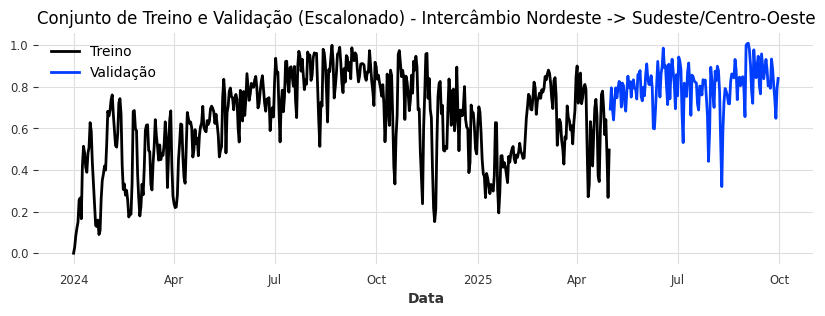

In [20]:
plt.figure(figsize=(10, 3))
train_scaled.plot(label="Treino")
val_scaled.plot(label="Validação")
plt.title('Conjunto de Treino e Validação (Escalonado) - Intercâmbio Nordeste -> Sudeste/Centro-Oeste')
plt.xlabel('Data')
plt.legend()

## Construir modelo

In [21]:
model_name = "TCN_Intercambio_NE_SECO_Diario_2024_2025"
my_model = TCNModel(
    input_chunk_length=56, # 8 semanas
    output_chunk_length=28,  # 4 semanas
    n_epochs=30,
    dropout=0.2,
    dilation_base=2,
    weight_norm=True,
    kernel_size=7,
    num_filters=28,
    nr_epochs_val_period=1,
    random_state=0,
    save_checkpoints=True,
    model_name=model_name,
    force_reset=True,
    **generate_torch_kwargs(),
)

## Treinar Modelo

In [22]:
my_model.fit(
    series=train_scaled,
    past_covariates=day_series,
    val_series=val_scaled,
    val_past_covariates=day_series,
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | res_blocks      | ModuleList       | 29.7 K | train
-------------------------------------------------------------
29.7 K    Trainable params
0         Non-trainable params
29.7 K    Total params
0.119     Total estimated model params size (MB)
41        Modules in train mode
0         Modules in eval mode


Training: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


TCNModel(output_chunk_shift=0, kernel_size=7, num_filters=28, num_layers=None, dilation_base=2, weight_norm=True, dropout=0.2, input_chunk_length=56, output_chunk_length=28, n_epochs=30, nr_epochs_val_period=1, random_state=0, save_checkpoints=True, model_name=TCN_Intercambio_NE_SECO_Diario_2024_2025, force_reset=True, pl_trainer_kwargs={'accelerator': 'cpu', 'callbacks': [<darts.utils.callbacks.TFMProgressBar object at 0x00000252DFB2D5B0>]})

## Carregar Modelo

In [23]:
my_model = TCNModel.load_from_checkpoint(model_name=model_name, best=True)

## Backtest

In [24]:
backtest = my_model.historical_forecasts(
    series=ts_scaled,
    past_covariates=day_series,
    start=val_scaled.start_time(),
    forecast_horizon=28, # 4 semanas
    stride=28, # 4 semanas
    last_points_only=False,
    retrain=False,
    verbose=True,
)
backtest = concatenate(backtest)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Generating TimeSeries:   0%|          | 0/5 [00:00<?, ?it/s]

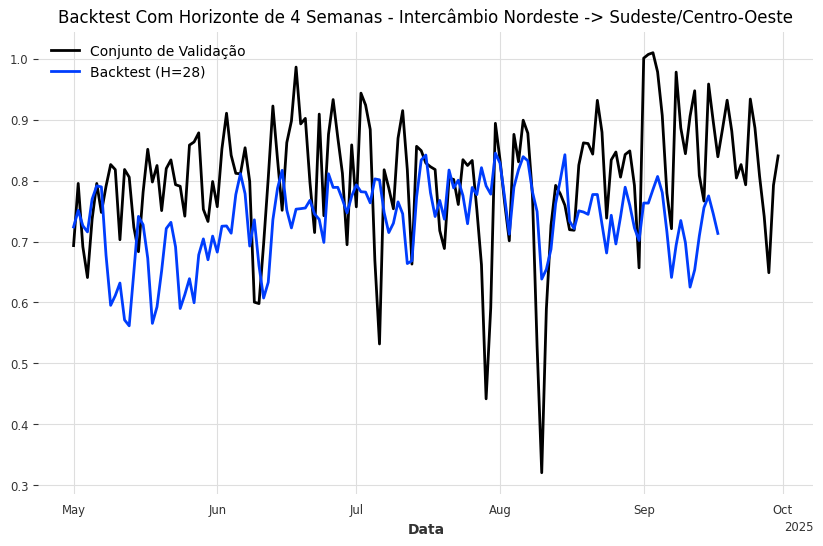

In [25]:
plt.figure(figsize=(10, 6))
val_scaled.plot(label="Conjunto de Validação")
backtest.plot(label="Backtest (H=28)")
plt.title('Backtest Com Horizonte de 4 Semanas - Intercâmbio Nordeste -> Sudeste/Centro-Oeste')
plt.xlabel('Data')
plt.legend()

In [26]:
from darts.metrics import mae, mse

print(f"MAE: {mae(val_scaled,backtest)}")
print(f"MSE: {mse(val_scaled,backtest)}")

MAE: 0.1063708922291288
MSE: 0.01739218791336704


In [27]:
# dados de outubro
real = TimeSeries.from_dataframe(dataframe_ne_seco_diario_compare, time_col="din_instante", value_cols=["val_intercambiomwmed"], freq="D")

# Previsão para o próximo mês (outubro de 2025)
pred_scaled = my_model.predict(
    n=28,
    series=ts,               # A partir de onde prever (fim do treino+validação)
    past_covariates=day_series # Covariáveis disponíveis (precisa conter os valores para o horizonte de previsão)
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


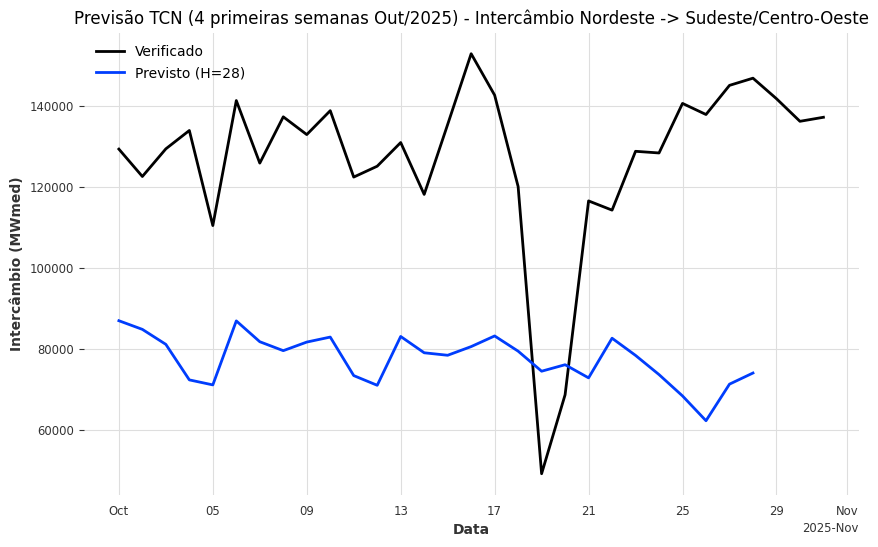

In [28]:
predicted = pred_scaled

plt.figure(figsize=(10, 6))
real.plot(label="Verificado")
pred_scaled.plot(label="Previsto (H=28)")
plt.title('Previsão TCN (4 primeiras semanas Out/2025) - Intercâmbio Nordeste -> Sudeste/Centro-Oeste')
plt.ylabel('Intercâmbio (MWmed)')
plt.xlabel('Data')
plt.legend()

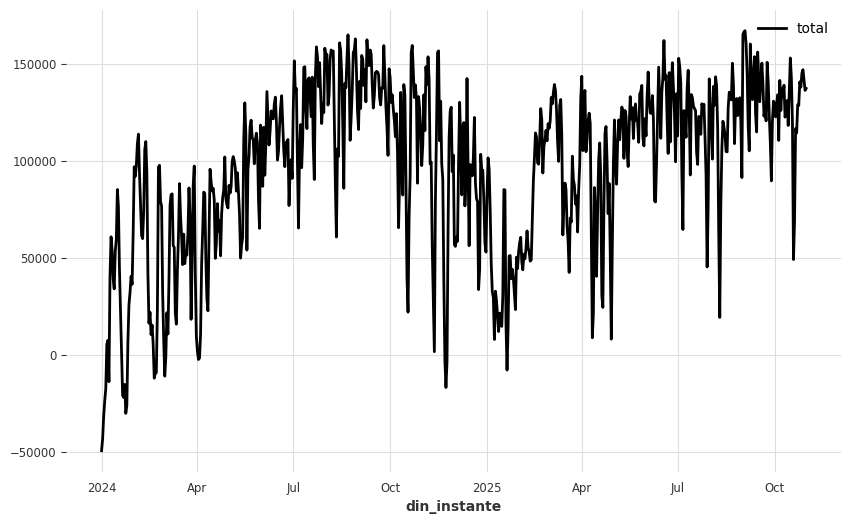

In [29]:
total = TimeSeries.from_dataframe(dataframe_ne_seco_diario, time_col="din_instante", value_cols=["val_intercambiomwmed"], freq="D")

plt.figure(figsize=(10, 6))
total.plot(label="total")
plt.legend()